# 07 - Classical PYMK Baseline Experiment

This notebook presents the reproducible Task 4 experiment for the People You May Know (PYMK) baseline. It reads the committed aggregate benchmark results, so it can be reviewed without downloading the raw MGTAB tensors.

**Research question:** when a known link is hidden from the observed graph, which classical topology scorer ranks it above plausible non-links?

## Experiment protocol

- Dataset: public MGTAB benchmark (raw tensors are intentionally not included in this repository).
- Split: train/validation/test = 70% / 15% / 15%, seed 42.
- Leakage control: validation and test positive links are masked before candidate generation and scoring.
- Tasks: directed `friends` reconstruction and reciprocal/mutual-pair reconstruction.
- Negatives: random non-links and hard two-hop candidates.
- Scorers: Random, Common Neighbors, Jaccard, Adamic-Adar, and Preferential Attachment.
- Metrics: ROC-AUC, Average Precision (AP), Recall@10, NDCG@10, Hits@10, and MRR.

This is a missing-link/link-reconstruction proxy on a snapshot, not temporal future-friendship prediction.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name.lower() == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
RESULTS_DIR = PROJECT_ROOT / 'results' / 'classical_baselines'
RESULTS_PATH = RESULTS_DIR / 'results.csv'
CONFIG_PATH = RESULTS_DIR / 'config.json'

if not RESULTS_PATH.is_file():
    raise FileNotFoundError(f'Missing committed experiment results: {RESULTS_PATH}')

results = pd.read_csv(RESULTS_PATH)
with CONFIG_PATH.open(encoding='utf-8') as handle:
    config = json.load(handle)

assert len(results) == 20, f'Expected 20 benchmark rows, found {len(results)}'
print(f'Loaded {len(results)} experiment rows from {RESULTS_PATH.relative_to(PROJECT_ROOT)}')

Loaded 20 experiment rows from results\classical_baselines\results.csv


In [2]:
protocol = pd.DataFrame({
    'Setting': ['Seed', 'Split', 'Test-positive cap per task', 'Ranking negatives per query', 'Directed strategy', 'Evaluation stage'],
    'Value': [
        config['seed'],
        f"{config['train_ratio']:.0%} / {config['val_ratio']:.0%} / {config['test_ratio']:.0%}",
        config['max_positive_pairs'],
        config['ranking_negatives_per_query'],
        config['directed_strategy'],
        config['evaluation_stage'],
    ],
})
display(protocol)

,Setting,Value
0,Seed,42
1,Split,70% / 15% / 15%
2,Test-positive cap per task,100
3,Ranking negatives per query,30
4,Directed strategy,out_out
5,Evaluation stage,test_after_validation_pipeline_check


## Full benchmark results

The two compact tables below contain all 20 configurations: 2 tasks x 2 negative modes x 5 scorers. Random negatives are easier; the hard two-hop condition is the more realistic PYMK-style candidate setting.

In [3]:
binary_columns = ['task', 'negative_mode', 'scorer', 'roc_auc', 'average_precision']
ranking_columns = ['task', 'negative_mode', 'scorer', 'recall_at_10', 'ndcg_at_10', 'mrr']

for title, columns in [('Binary metrics', binary_columns), ('Ranking metrics', ranking_columns)]:
    table = results[columns].copy()
    for column in columns[3:]:
        table[column] = table[column].round(4)
    print(title)
    display(table.sort_values(['task', 'negative_mode', 'scorer']).reset_index(drop=True))

Binary metrics


,task,negative_mode,scorer,roc_auc,average_precision
0,directed,hard,adamic_adar,0.6927,0.6989
1,directed,hard,common_neighbors,0.6837,0.6851
2,directed,hard,jaccard,0.6969,0.6821
3,directed,hard,preferential_attachment,0.5654,0.6235
4,directed,hard,random,0.4649,0.4893
5,directed,random,adamic_adar,0.9048,0.9113
6,directed,random,common_neighbors,0.9110,0.9150
7,directed,random,jaccard,0.8786,0.8768
8,directed,random,preferential_attachment,0.8828,0.8969
9,directed,random,random,0.4806,0.5199


Ranking metrics


,task,negative_mode,scorer,recall_at_10,ndcg_at_10,mrr
0,directed,hard,adamic_adar,0.6591,0.3706,0.3024
1,directed,hard,common_neighbors,0.6250,0.3779,0.3249
2,directed,hard,jaccard,0.6477,0.3720,0.3098
3,directed,hard,preferential_attachment,0.4659,0.2774,0.2477
4,directed,hard,random,0.2841,0.1420,0.1364
5,directed,random,adamic_adar,0.9432,0.6991,0.6248
6,directed,random,common_neighbors,0.9659,0.7160,0.6379
7,directed,random,jaccard,0.9432,0.7011,0.6278
8,directed,random,preferential_attachment,0.8636,0.5156,0.4154
9,directed,random,random,0.2841,0.1293,0.1196


## Hard-negative comparison

Hard negatives are two-hop candidates that resemble plausible recommendations. The charts compare the ranking-oriented NDCG@10 and pairwise ROC-AUC across scorers.

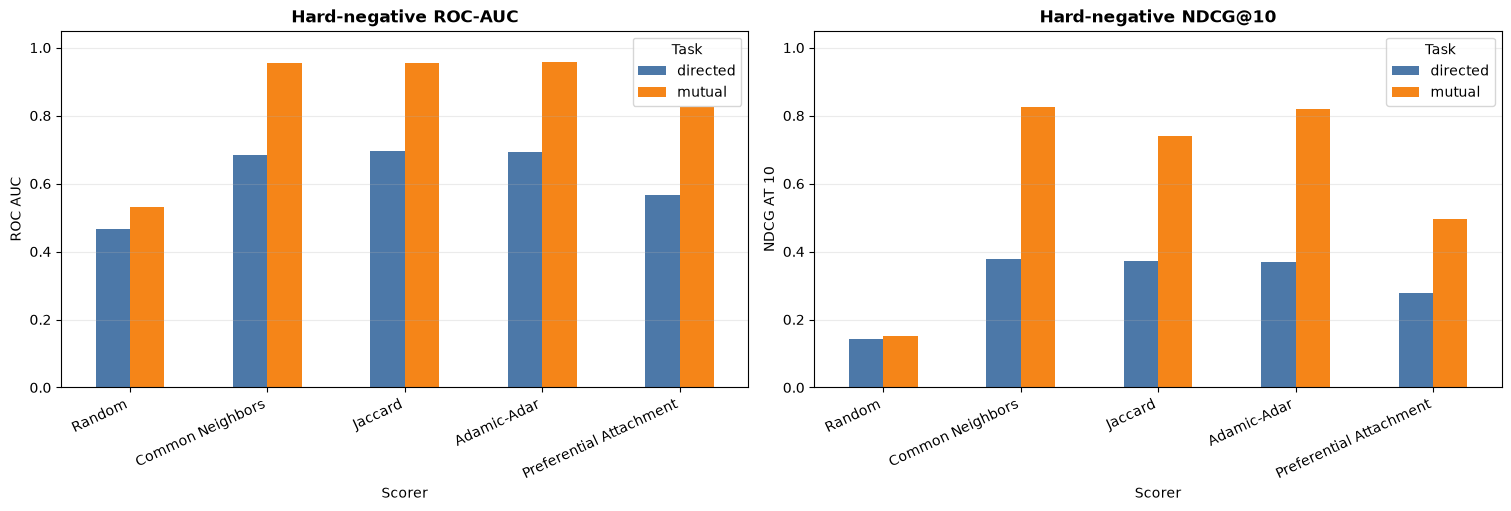

In [4]:
hard = results.loc[results['negative_mode'].eq('hard')].copy()
scorer_order = ['random', 'common_neighbors', 'jaccard', 'adamic_adar', 'preferential_attachment']
labels = ['Random', 'Common Neighbors', 'Jaccard', 'Adamic-Adar', 'Preferential Attachment']

fig, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)
for axis, metric, title in zip(axes, ['roc_auc', 'ndcg_at_10'], ['Hard-negative ROC-AUC', 'Hard-negative NDCG@10']):
    pivot = hard.pivot(index='scorer', columns='task', values=metric).reindex(scorer_order)
    pivot.plot(kind='bar', ax=axis, color=['#4C78A8', '#F58518'])
    axis.set_title(title, fontweight='bold')
    axis.set_xlabel('Scorer')
    axis.set_ylabel(metric.replace('_', ' ').upper())
    axis.set_ylim(0, 1.05)
    axis.set_xticklabels(labels, rotation=25, ha='right')
    axis.legend(title='Task')
    axis.grid(axis='y', alpha=0.25)
plt.show()

In [5]:
mutual_hard = hard.loc[hard['task'].eq('mutual')].copy()
best_auc = mutual_hard.loc[mutual_hard['roc_auc'].idxmax()]
best_ndcg = mutual_hard.loc[mutual_hard['ndcg_at_10'].idxmax()]

summary = pd.DataFrame([
    {'Selection criterion': 'Best ROC-AUC', 'Scorer': best_auc['scorer'], 'Value': best_auc['roc_auc']},
    {'Selection criterion': 'Best AP', 'Scorer': mutual_hard.loc[mutual_hard['average_precision'].idxmax(), 'scorer'], 'Value': mutual_hard['average_precision'].max()},
    {'Selection criterion': 'Best NDCG@10', 'Scorer': best_ndcg['scorer'], 'Value': best_ndcg['ndcg_at_10']},
    {'Selection criterion': 'Candidate coverage', 'Scorer': 'two-hop pool', 'Value': mutual_hard['candidate_coverage'].iloc[0]},
])
summary['Value'] = summary['Value'].round(4)
display(summary)

print('Conclusion: Mutual + hard negatives is the current application proxy.')
print(f"{best_auc['scorer']} leads ROC-AUC ({best_auc['roc_auc']:.4f}); {best_ndcg['scorer']} leads NDCG@10 ({best_ndcg['ndcg_at_10']:.4f}).")

,Selection criterion,Scorer,Value
0,Best ROC-AUC,adamic_adar,0.9585
1,Best AP,jaccard,0.9459
2,Best NDCG@10,common_neighbors,0.8261
3,Candidate coverage,two-hop pool,1.0000


Conclusion: Mutual + hard negatives is the current application proxy.
adamic_adar leads ROC-AUC (0.9585); common_neighbors leads NDCG@10 (0.8261).


## Interpretation and limitations

- Mutual has candidate coverage of 1.00 in this deterministic sample; all hidden positives are in the two-hop pool before ranking.
- Directed is retained as an auxiliary benchmark and has lower two-hop coverage.
- The default run samples at most 100 test positives per task for reproducible local runtime. It is not a production-scale benchmark.
- The experiment does not claim temporal future-link prediction and does not use bot labels to make a fraud decision.

For the implementation and the complete generated report, see `scripts/run_classical_experiments.py` and `docs/directed_vs_mutual_experiment.md`.

## Re-run the benchmark (optional)

To reproduce the benchmark from raw data, first download MGTAB as described in the repository README and place it in `data/raw/MGTAB/`. Then run this command from the repository root:

```powershell
.\.venv\Scripts\python.exe scripts\run_classical_experiments.py
```

Re-run the data-loading cells in this notebook afterward to refresh the displayed results.